In [15]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import sys
sys.path.append("..")
from utils.spatial import is_dominated
from constants import RESULTS_DATA_DIR,RESULTS_DIR

In [16]:
ALGO = "weighted_fpgrowth"

results_df = pd.read_csv(f"../{RESULTS_DIR}/{ALGO}/data/results_CN.csv")
print("Results columns:", results_df.columns)

Results columns: Index(['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction',
       'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort',
       'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD',
       'liver stage', 'skin stage', 'Pathological stage', 'Clinical score',
       'Pathological score', 'Group'],
      dtype='str')


Summary stats for unique rules per FOV:
count    288.000000
mean     429.232639
std      176.849977
min       60.000000
25%      307.250000
50%      439.000000
75%      547.500000
max      979.000000
Name: Rule, dtype: float64


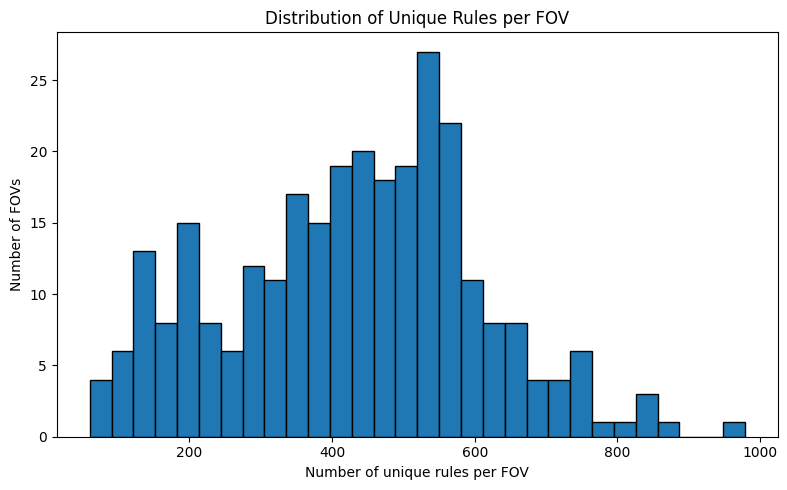

In [12]:
import matplotlib.pyplot as plt

# Define a rule as Antecedents -> Consequents and count unique rules per FOV
tmp = results_df.assign(
    Rule=results_df["Antecedents"].astype(str) + " -> " + results_df["Consequents"].astype(str)
)
unique_rules_per_fov = tmp.groupby("FOV")["Rule"].nunique()

print("Summary stats for unique rules per FOV:")
print(unique_rules_per_fov.describe())

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(unique_rules_per_fov, bins=30, edgecolor="black")
plt.xlabel("Number of unique rules per FOV")
plt.ylabel("Number of FOVs")
plt.title("Distribution of Unique Rules per FOV")
plt.tight_layout()
plt.show()

Lift summary per FOV:
                  count      mean       std       min       25%       50%  \
FOV                                                                         
Control_01_FOV_1  826.0  5.558988  1.691361  0.704310  4.786491  5.262097   
Control_01_FOV_2  347.0  3.394299  2.696932  0.412264  0.720389  3.894649   
Control_01_FOV_3  654.0  7.281673  3.446560  0.556114  7.447302  8.304099   
Control_01_FOV_4  564.0  1.963295  1.422555  0.514373  0.703561  0.764890   
Control_02_FOV_1  516.0  7.168078  3.391285  0.449283  7.181199  7.332988   

                       75%        max  
FOV                                    
Control_01_FOV_1  6.391616  12.576551  
Control_01_FOV_2  4.651806  16.043628  
Control_01_FOV_3  8.945967  12.086520  
Control_01_FOV_4  2.971429   5.700146  
Control_02_FOV_1  8.725456  14.604721  


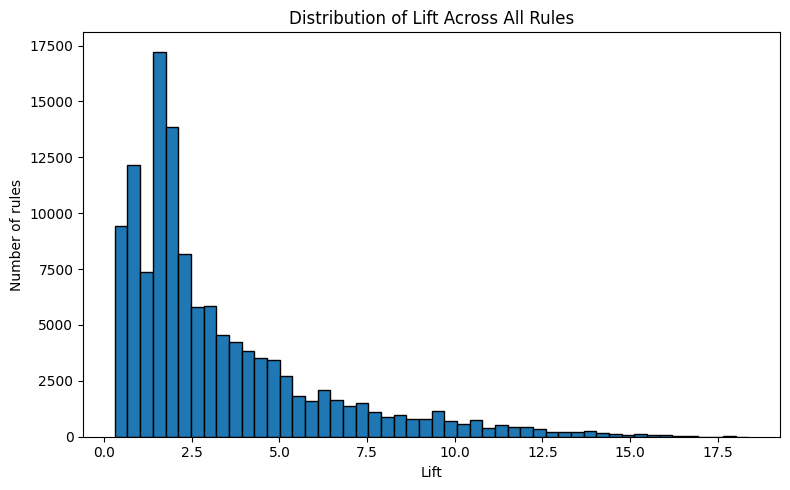

<Figure size 800x500 with 0 Axes>

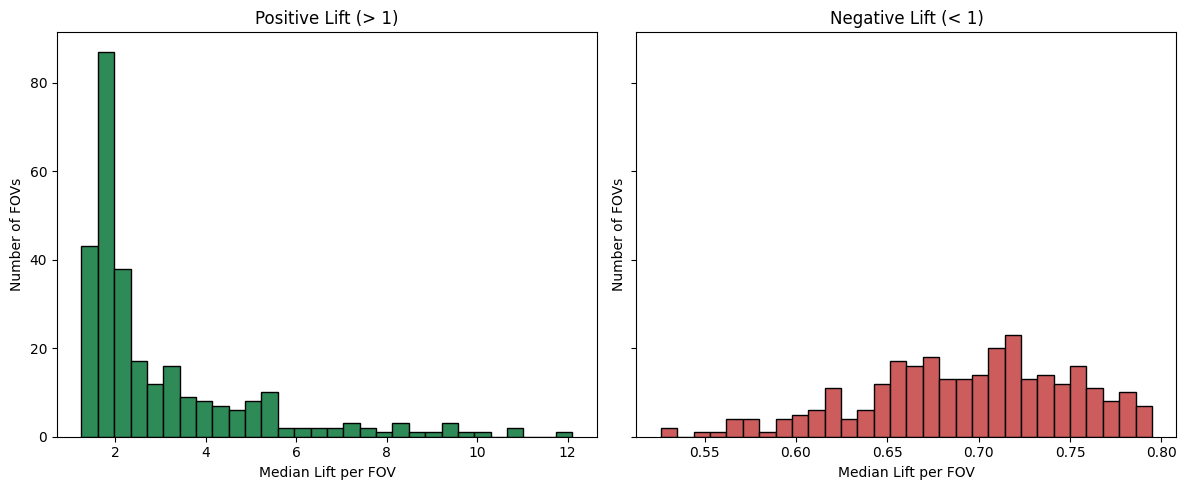

In [13]:
# Distribution of lift values across rules, summarized per FOV
lift_stats_per_fov = results_df.groupby("FOV")["Lift"].describe()

print("Lift summary per FOV:")
print(lift_stats_per_fov[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].head())

# Histogram of all lift values
plt.figure(figsize=(8, 5))
plt.hist(results_df["Lift"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Lift")
plt.ylabel("Number of rules")
plt.title("Distribution of Lift Across All Rules")
plt.tight_layout()
plt.show()

# Histogram of per-FOV median lift
# Compute separate per-FOV medians for positive and negative lift, then combine
median_pos_lift_per_fov = results_df[results_df["Lift"] > 1].groupby("FOV")["Lift"].median()
median_neg_lift_per_fov = results_df[results_df["Lift"] < 1].groupby("FOV")["Lift"].median()

# Keep a single series for downstream histogram/splitting code
median_lift_per_fov = pd.concat([median_pos_lift_per_fov, median_neg_lift_per_fov])

plt.figure(figsize=(8, 5))
plt.hist(median_lift_per_fov.dropna(), bins=30, edgecolor="black")
plt.xlabel("Median Lift per FOV")
plt.ylabel("Number of FOVs")
plt.title("Distribution of Median Lift per FOV")
plt.tight_layout()
plt.clf()

positive_lift = median_lift_per_fov[median_lift_per_fov > 1].dropna()
negative_lift = median_lift_per_fov[median_lift_per_fov < 1].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(positive_lift, bins=30, edgecolor="black", color="seagreen")
axes[0].set_title("Positive Lift (> 1)")
axes[0].set_xlabel("Median Lift per FOV")
axes[0].set_ylabel("Number of FOVs")

axes[1].hist(negative_lift, bins=30, edgecolor="black", color="indianred")
axes[1].set_title("Negative Lift (< 1)")
axes[1].set_xlabel("Median Lift per FOV")
axes[1].set_ylabel("Number of FOVs")

plt.tight_layout()
plt.show()

In [14]:
# Keep rules with strong positive or negative association
lift_keep_mask = (results_df["Lift"] > 1.3) | (results_df["Lift"] < 0.7)

n_total_rules = len(results_df)
n_kept_rules = lift_keep_mask.sum()
n_removed_rules = n_total_rules - n_kept_rules
pct_kept = 100 * n_kept_rules / n_total_rules

print(f"Total rules:   {n_total_rules:,}")
print(f"Kept rules:    {n_kept_rules:,} ({pct_kept:.2f}%)")
print(f"Removed rules: {n_removed_rules:,}")

# Optional: split kept rules by side of threshold
n_gt_13 = (results_df["Lift"] > 1.3).sum()
n_lt_07 = (results_df["Lift"] < 0.7).sum()
print(f"\nKept with Lift > 1.3: {n_gt_13:,}")
print(f"Kept with Lift < 0.7: {n_lt_07:,}")

Total rules:   123,619
Kept rules:    110,036 (89.01%)
Removed rules: 13,583

Kept with Lift > 1.3: 97,999
Kept with Lift < 0.7: 12,037


### Support Value Distribution

Support summary per FOV:
                  count      mean       std       min       25%       50%  \
FOV                                                                         
Control_01_FOV_1  780.0  0.013697  0.003010  0.010003  0.011447  0.013096   
Control_01_FOV_2  840.0  0.014446  0.004833  0.010016  0.011026  0.012628   
Control_01_FOV_3  872.0  0.012618  0.002416  0.010019  0.010889  0.011733   
Control_01_FOV_4  860.0  0.015060  0.006473  0.010009  0.010989  0.012978   
Control_02_FOV_1  714.0  0.013871  0.004221  0.010025  0.010784  0.012481   

                       75%       max  
FOV                                   
Control_01_FOV_1  0.015054  0.029406  
Control_01_FOV_2  0.015753  0.041005  
Control_01_FOV_3  0.013458  0.023925  
Control_01_FOV_4  0.016509  0.073320  
Control_02_FOV_1  0.015363  0.034524  


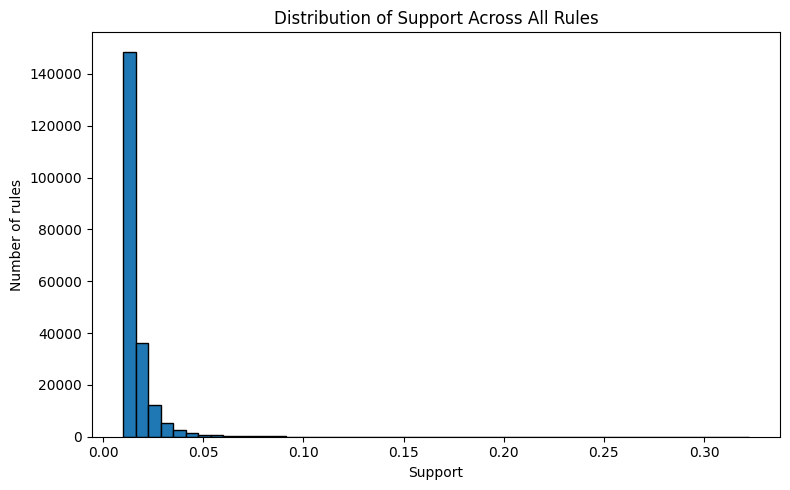

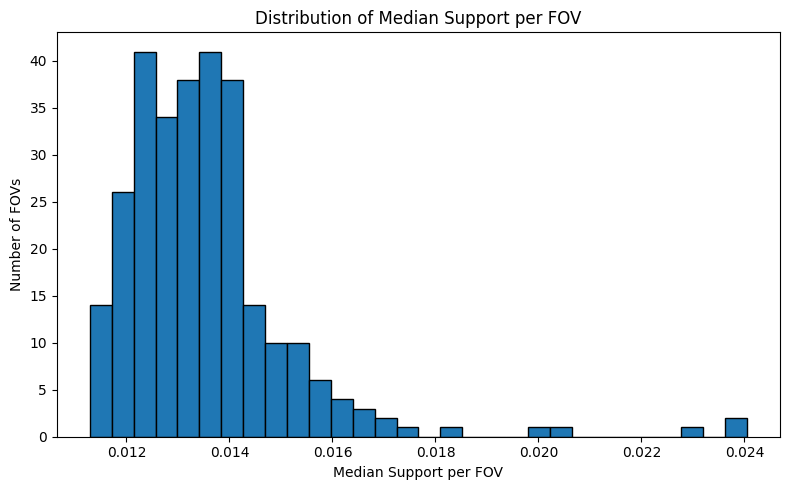

In [22]:
# Distribution of support values across rules, summarized per FOV
support_stats_per_fov = results_df.groupby("FOV")["Support"].describe()

print("Support summary per FOV:")
print(support_stats_per_fov[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].head())

# Histogram of all support values
plt.figure(figsize=(8, 5))
plt.hist(results_df["Support"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Support")
plt.ylabel("Number of rules")
plt.title("Distribution of Support Across All Rules")
plt.tight_layout()
plt.show()

# Histogram of median support per FOV
median_support_per_fov = results_df.groupby("FOV")["Support"].median()

plt.figure(figsize=(8, 5))
plt.hist(median_support_per_fov.dropna(), bins=30, edgecolor="black")
plt.xlabel("Median Support per FOV")
plt.ylabel("Number of FOVs")
plt.title("Distribution of Median Support per FOV")
plt.tight_layout()
plt.show()

In [25]:
print("Total rules:", len(results_df))
print("Rules with Support > 0.03:", (results_df["Support"] > 0.03).sum())
print("Rules with Support > 0.04:", (results_df["Support"] > 0.04).sum())
print("Rules with Support > 0.05:", (results_df["Support"] > 0.05).sum())

Total rules: 209516
Rules with Support > 0.03: 10903
Rules with Support > 0.04: 4717
Rules with Support > 0.05: 2569
